# [Pleione - 28 Tau](../../../Costellazioni/Taurus/Pleione.html) del [11/01/2026](../Index.html)

In [1]:
import sys
sys.path.append('../../../src')
import spectrum as spec
import pandas as pd

## Camera Settings

- Gain=100
- Exposure=120.000s
- Brightness=5
- Temperature=-10
- StartCapture=2026-01-11T17:56:04.3913318Z
- EndCapture=2026-01-11T18:56:20.6853020Z































## Raw Spectrum

Spettro ottenuto come media di 30 immagini. Applicati bias, dark e flat. Elaborazione con ISIS

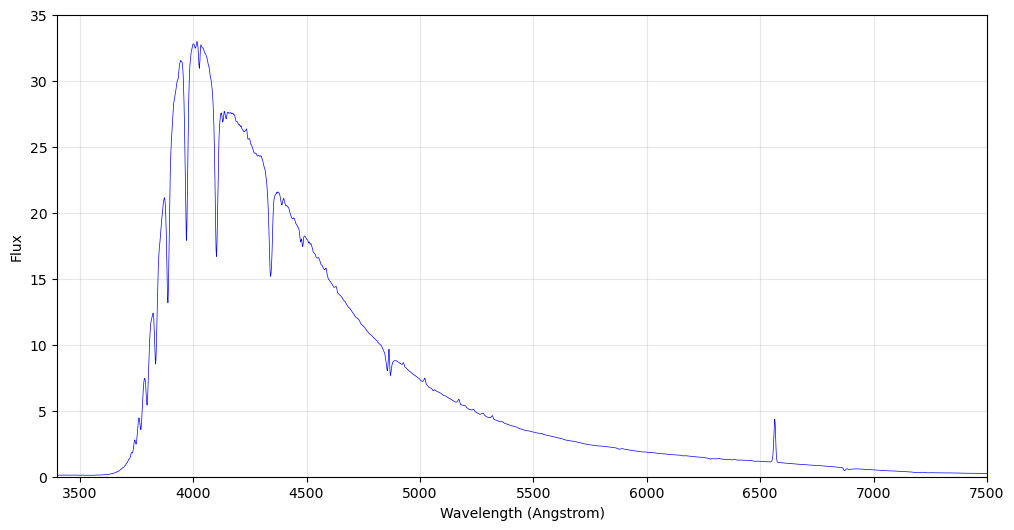

In [3]:
raw_wavelength, raw_flux = spec.load("_pleione_20260111_747.fit")
raw_flux = spec.cleanup_flux(raw_flux)
spec.simple_plot(raw_wavelength, raw_flux, wl_range = (3400, 7500), flux_range=(0.0,35.0))

## Response Corrected Spectrum

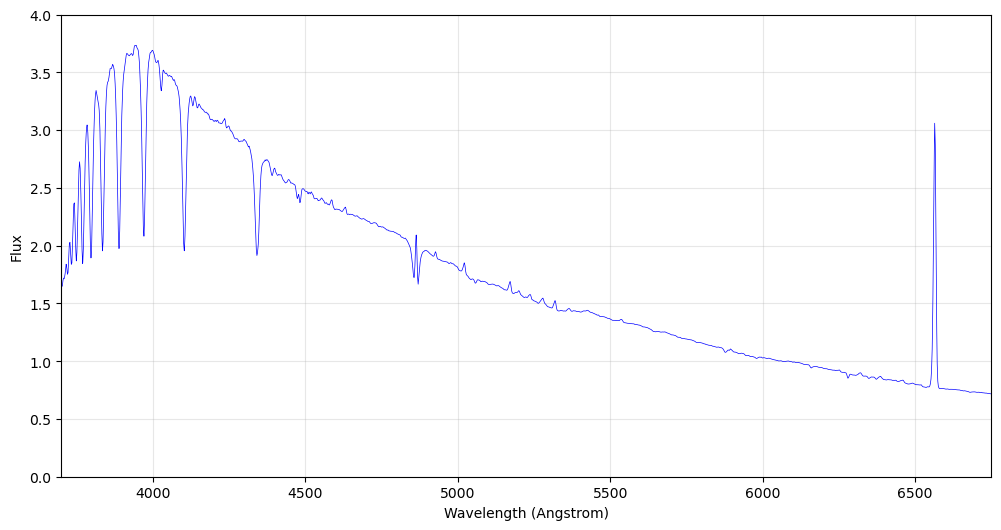

In [7]:
rc_wavelength, rc_flux = spec.load("_pleione_20260111_747-resp-corr.fit")
rc_flux = spec.cleanup_flux(rc_flux)
spec.simple_plot(rc_wavelength, rc_flux, wl_range = (3700, 6750), flux_range=(0.0,4.0))

## Rectified Spectrum

In [8]:
wavelength, flux = spec.load("_pleione_20260111_747-rect.fit")
flux = spec.cleanup_flux(flux)
print(f"SNR Reale stimato: {spec.calc_snr(wavelength, flux, 6730, 6830):.1f}")

SNR Reale stimato: 936.3


In [13]:
spectral_lines_summary = pd.read_csv('Pleione spec - Summary.csv', usecols=[0, 1, 2], names=["name","class","wavelength"])
#spectral_lines_all = pd.read_csv('Atlas spec - 2026-01-11.csv', usecols=[0, 1, 2], names=["name","class","wavelength"])

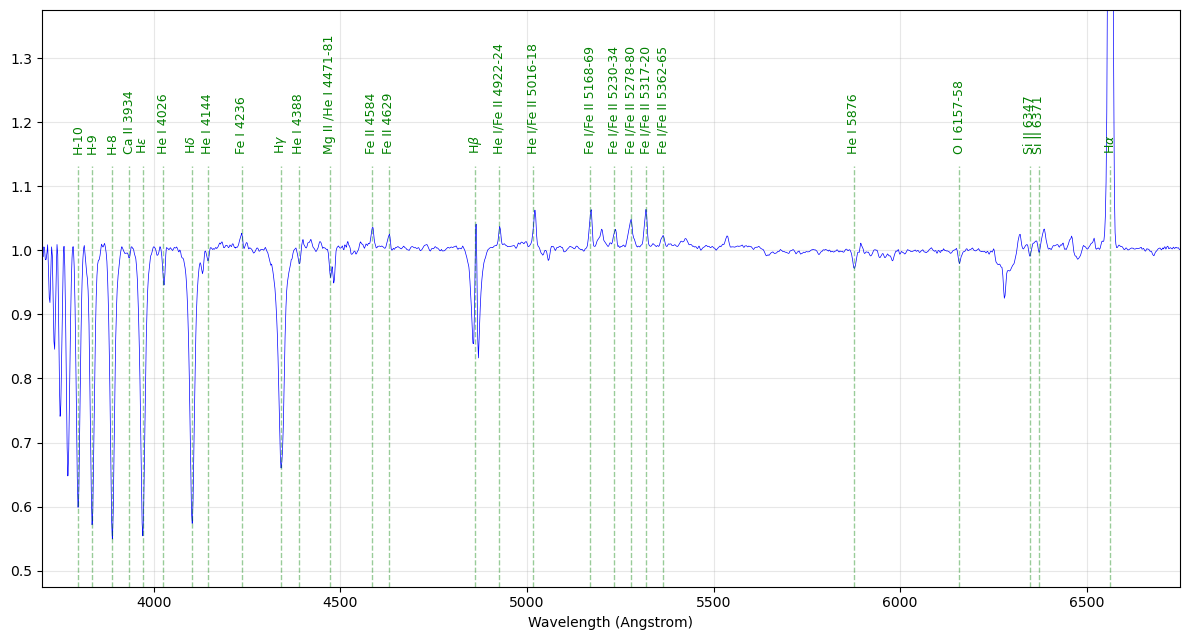

In [16]:
spec.plot_with_lines(wavelength, flux, spectral_lines_summary, (3700,6750), (0.475,1.375))